Primeras 5 filas de las respuestas simuladas:
   Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  Item_8  Item_9  \
0       4       5       3       5       5       2       3       3       3   
1       3       3       2       4       4       3       4       4       1   
2       4       4       4       5       3       1       4       2       4   
3       2       1       4       4       4       5       1       5       5   
4       4       1       4       2       1       5       3       4       3   

   Item_10  ...  Item_16  Item_17  Item_18  Item_19  Item_20  Item_21  \
0        5  ...        2        4        5        1        4        2   
1        3  ...        4        1        4        2        2        1   
2        2  ...        4        2        2        4        4        1   
3        1  ...        3        1        3        3        1        3   
4        3  ...        5        2        3        1        2        2   

   Item_22  Item_23  Item_24  Item_25  
0        5  

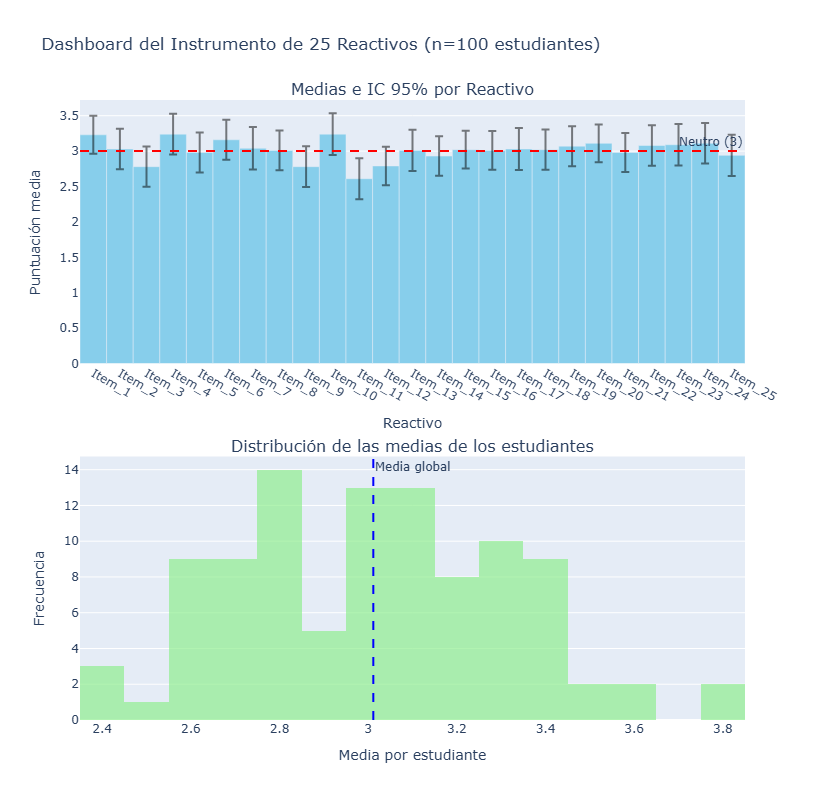

In [3]:
# -*- coding: utf-8 -*-
"""
Simulación de respuestas a un instrumento de 27 reactivos (Likert 1-5)
para 100 estudiantes. Cálculo de medias e intervalos de confianza.
Dashboard interactivo con Plotly.
"""

import numpy as np
import pandas as pd
import scipy.stats as stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# -------------------------------
# 1. Simulación de las respuestas
# -------------------------------
np.random.seed(42)  # Para reproducibilidad

n_estudiantes = 100
n_reactivos = 25
escala_min = 1
escala_max = 5

# Simulación independiente uniforme para cada reactivo
respuestas = np.random.randint(escala_min, escala_max + 1,
                               size=(n_estudiantes, n_reactivos))

# Convertir a DataFrame para mejor manejo
columnas = [f"Item_{i+1}" for i in range(n_reactivos)]
df_respuestas = pd.DataFrame(respuestas, columns=columnas)

print("Primeras 5 filas de las respuestas simuladas:")
print(df_respuestas.head())

# -----------------------------------------
# 2. Funciones para medias e intervalos de confianza
# -----------------------------------------
def media_ic(data, confidence=0.95):
    """
    Calcula la media y el intervalo de confianza para cada columna.
    Parámetros:
        data: DataFrame o array 2D
        confidence: nivel de confianza (0.95 por defecto)
    Retorna:
        DataFrame con media, límite inferior y superior del IC
    """
    if isinstance(data, pd.DataFrame):
        data = data.values
    n = data.shape[0]
    medias = np.mean(data, axis=0)
    s = np.std(data, axis=0, ddof=1)  # desviación muestral
    error = s / np.sqrt(n)
    # Usar distribución t de Student (más apropiada para muestras pequeñas)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n-1)
    ic_inferior = medias - t_crit * error
    ic_superior = medias + t_crit * error
    resultados = pd.DataFrame({
        'Media': medias,
        'IC_inferior': ic_inferior,
        'IC_superior': ic_superior
    }, index=columnas)
    return resultados

# Calcular medias e IC
resultados_ic = media_ic(df_respuestas)
print("\nMedias e intervalos de confianza (95%):")
print(resultados_ic.head())

# Función adicional para obtener resumen descriptivo rápido
def resumen_descriptivo(data):
    """Devuelve estadísticas descriptivas básicas por reactivo."""
    desc = data.describe().T
    return desc[['mean', 'std', 'min', 'max']]

print("\nResumen descriptivo por reactivo:")
print(resumen_descriptivo(df_respuestas).head())

# -----------------------------------------
# 3. Dashboard interactivo con Plotly
# -----------------------------------------
# Gráfico de barras con intervalos de confianza
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Medias e IC 95% por Reactivo",
                    "Distribución de las medias de los estudiantes"),
    vertical_spacing=0.15
)

# Gráfico de barras con IC
fig.add_trace(
    go.Bar(
        x=resultados_ic.index,
        y=resultados_ic['Media'],
        error_y=dict(
            type='data',
            symmetric=False,
            array=resultados_ic['IC_superior'] - resultados_ic['Media'],
            arrayminus=resultados_ic['Media'] - resultados_ic['IC_inferior'],
            color='rgba(0,0,0,0.5)'
        ),
        marker_color='skyblue',
        name='Media (IC 95%)',
        hovertemplate='Reactivo: %{x}<br>Media: %{y:.2f}<br>IC: [%{customdata[0]:.2f}, %{customdata[1]:.2f}]<extra></extra>',
        customdata=np.column_stack((resultados_ic['IC_inferior'], resultados_ic['IC_superior']))
    ),
    row=1, col=1
)

# Añadir línea horizontal en 3 (punto medio de la escala)
fig.add_hline(y=3, line_dash="dash", line_color="red",
              annotation_text="Neutro (3)", annotation_position="top right",
              row=1, col=1)

# Gráfico de distribución de medias por estudiante
medias_est = df_respuestas.mean(axis=1)
fig.add_trace(
    go.Histogram(x=medias_est, nbinsx=20, name='Media por estudiante',
                 marker_color='lightgreen', opacity=0.7),
    row=2, col=1
)
fig.add_vline(x=medias_est.mean(), line_dash="dash", line_color="blue",
              annotation_text="Media global", annotation_position="top right",
              row=2, col=1)

# Actualizar layout
fig.update_layout(
    title="Dashboard del Instrumento de 25 Reactivos (n=100 estudiantes)",
    showlegend=False,
    height=800,
    width=1000
)
fig.update_xaxes(title_text="Reactivo", row=1, col=1)
fig.update_yaxes(title_text="Puntuación media", row=1, col=1)
fig.update_xaxes(title_text="Media por estudiante", row=2, col=1)
fig.update_yaxes(title_text="Frecuencia", row=2, col=1)

# Mostrar el dashboard (se abrirá en el navegador si se ejecuta en Jupyter/entorno adecuado)
fig.show()

# Opcional: guardar como HTML
#fig.write_html("dashboard_reactivos.html")
#print("\nDashboard guardado como 'dashboard_reactivos.html'")